In [1]:
from fastai.vision.all import *

In [2]:
def label_func(f):
  name = f.name
  return name[0].isupper()

splitter = RandomSplitter(valid_pct=0.2)

pets = DataBlock(blocks=(ImageBlock, CategoryBlock),  # définition du TYPE d'entrée / sortie
                 get_items=get_image_files,           # définition du CHARGEMENT des entrées
                 get_y = label_func,                  # définition du CHARGEMENT des sorties
                 splitter=splitter)                   # définition de la SEPARATION des données (train, validation)

In [3]:
pets = DataBlock(blocks=(ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 get_y = label_func,
                 splitter=splitter,
                 item_tfms=Resize((200,200)))          # Changer la résolution les images pour obtenir une taille de 100x100 pour toutes

torch.Size([8, 3, 200, 200])


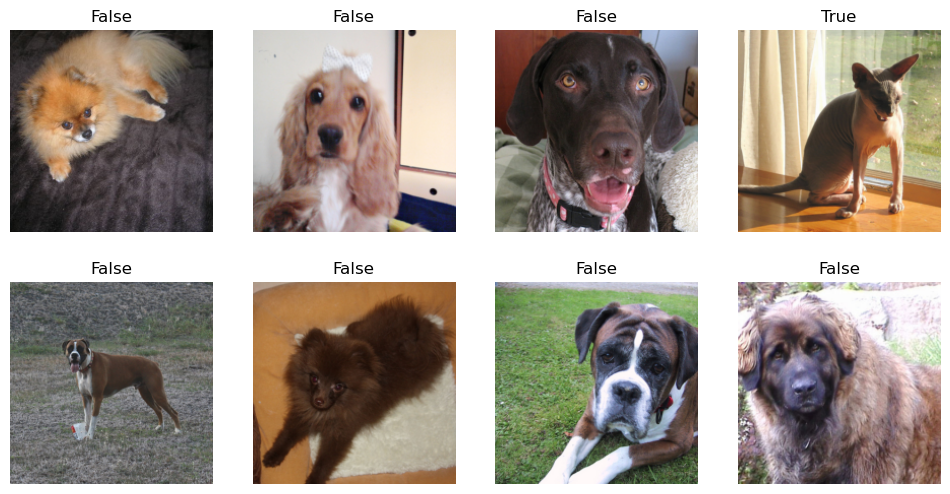

In [4]:
dls = pets.dataloaders(untar_data(URLs.PETS)/"images", bs=8) #Ici, entrée = liste de paths
dls.show_batch()
print(dls.one_batch()[0].shape)

torch.Size([8, 3, 200, 200])


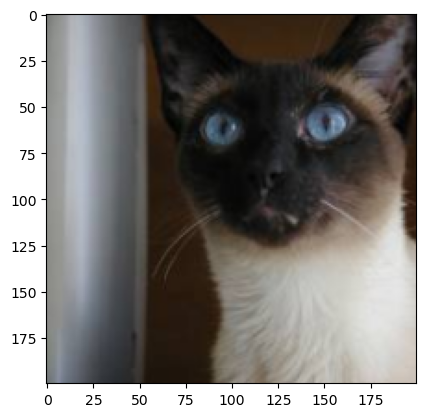

In [5]:
import matplotlib.pyplot as plt
batch1 = dls.one_batch()[0]
print(batch1.shape)
b = batch1[0]
plt.imshow(b.cpu().permute(1,2,0))


In [ ]:
from scores_utils import compute_fft_scores

### Define the Dataloader
data_path = untar_data(URLs.PETS) #checker les autres databases dispo
print(data_path.ls())

catblock = MultiCategoryBlock(encoded=True, vocab=['cat', 'dog'])
dblock = DataBlock(
    blocks=(ImageBlock(), catblock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=label_func,
    item_tfms=Resize(128),
    batch_tfms=[Normalize.from_stats(*imagenet_stats)],
)

# Créez un DataLoader
dls = dblock.dataloaders(data_path/"images", bs=16, drop_last=True)


liste_fichiers = dls.train.items + dls.valid.items

scores_dict = compute_fft_scores(liste_fichiers)

#nombre d'images dont on a calculé le score
print(len(scores_dict))


[Path('/Users/arda/.fastai/data/oxford-iiit-pet/images'), Path('/Users/arda/.fastai/data/oxford-iiit-pet/annotations')]


/opt/anaconda3/envs/general/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Calcul des scores FFT: 100%|██████████| 7390/7390 [00:16<00:00, 454.67it/s]

7390
